<a href="https://colab.research.google.com/github/DanielaDSMS/Evidence-of-AI-related-skills/blob/main/challenge1_bilstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🌐 **Google Drive Connection**

In [ ]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/AN2DL/challenge1"
%cd $current_dir

Mounted at /gdrive
[Errno 2] No such file or directory: '/gdrive/My Drive/AN2DL/challenge1'
/content


## ⚙️ **Libraries** **Import**

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.utils.class_weight import compute_class_weight

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
from torch.cuda.amp import GradScaler

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0+cu126
Device: cuda


## ⏳ **Data Loading**

In [ ]:

# Set environment variables for dataset paths
os.environ["TRAIN_FILE"] = "pirate_pain_train.csv"
os.environ["TRAIN_URL"] = "1yRqrSB1JQwH09p1fXpO7lNfQZBl0PSBs"
os.environ["LABEL_FILE"] = "pirate_pain_train_labels.csv"
os.environ["LABEL_URL"] = "1BhWWiWQeBt9R4BcenRjzuuO0-VKQV8oJ"
os.environ["TEST_FILE"] = "pirate_pain_test.csv"
os.environ["TEST_URL"] = "1fXPfRottySriJF2uyRzpUgOI5affanMa"

# Check if Activity Recognition dataset exists and download if not
if not os.path.exists(os.environ["TRAIN_FILE"]):
    print("Downloading Activity Recognition dataset...")
    !gdown -q ${TRAIN_URL} -O ${TRAIN_FILE}
    print("Activity Recognition dataset1 downloaded!")
else:
    print("Activity Recognition dataset1 already downloaded. Using cached data.")

if not os.path.exists(os.environ["LABEL_FILE"]):
    print("Downloading Activity Recognition dataset...")
    !gdown -q ${LABEL_URL} -O ${LABEL_FILE}
    print("Activity Recognition dataset2 downloaded!")
else:
    print("Activity Recognition dataset2 already downloaded. Using cached data.")

if not os.path.exists(os.environ["TEST_FILE"]):
    print("Downloading Activity Recognition dataset...")
    !gdown -q ${TEST_URL} -O ${TEST_FILE}
    print("Activity Recognition dataset3 downloaded!")
else:
    print("Activity Recognition dataset3 already downloaded. Using cached data.")



Activity Recognition dataset1 downloaded!
Activity Recognition dataset2 downloaded!
Activity Recognition dataset3 downloaded!


## 🔎 **Exploration and Data Analysis**


In [ ]:
# Load the dataset from a CSV file
dataset_train = pd.read_csv('pirate_pain_train.csv')
dataset_labels = pd.read_csv('pirate_pain_train_labels.csv')
dataset_test = pd.read_csv('pirate_pain_test.csv')

# Print the shape of the dataset
print(f"Dataset shape: {dataset_train.shape}")
print(f"Dataset shape: {dataset_labels.shape}")

# Display the first few rows of the dataset
dataset_train.head()
#661 is the number of people

Dataset shape: (105760, 40)
Dataset shape: (661, 2)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


In [ ]:

#Everyone did 160 seconds or 2 min
counts_per_sample = dataset_train.groupby('sample_index')['time'].count()
all_160_timesteps = (counts_per_sample == 160).all()
print(f"All subjects have 160 time steps: {all_160_timesteps}")

All subjects have 160 time steps: True


In [ ]:
print(dataset_train.isna().mean().sort_values(ascending=False).head(10))
print(dataset_train['sample_index'].nunique(), dataset_labels['sample_index'].nunique())

sample_index     0.0
time             0.0
pain_survey_1    0.0
pain_survey_2    0.0
pain_survey_3    0.0
pain_survey_4    0.0
n_legs           0.0
n_hands          0.0
n_eyes           0.0
joint_00         0.0
dtype: float64
661 661


- No missing values: All columns show a mean of 0.0 for null values, meaning the dataset is clean and doesn't require imputation or removal of NaNs.

- Subject count consistency: Both dataset_train and dataset_labels contain 661 unique sample_index entries, confirming alignment between features and labels.

dataset_train['sample_index'].nunique() = 661

dataset_labels['sample_index'].nunique() = 661

# Is it balance or imbalance?

In [ ]:
dataset_labels['label'].value_counts()

,count
label,
no_pain,511
low_pain,94
high_pain,56


In [ ]:
dataset_labels['label'].value_counts(normalize=True)

,proportion
label,
no_pain,0.773071
low_pain,0.142209
high_pain,0.084720


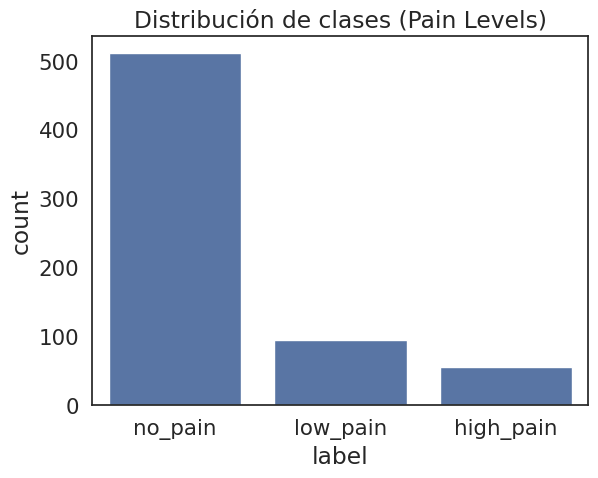

In [ ]:
sns.countplot(data=dataset_labels, x='label')
plt.title('Distribución de clases (Pain Levels)')
plt.show()


Result: class imbalance, tend to no_pain

# NOISE


# Step 1: Visual inspection (plots)

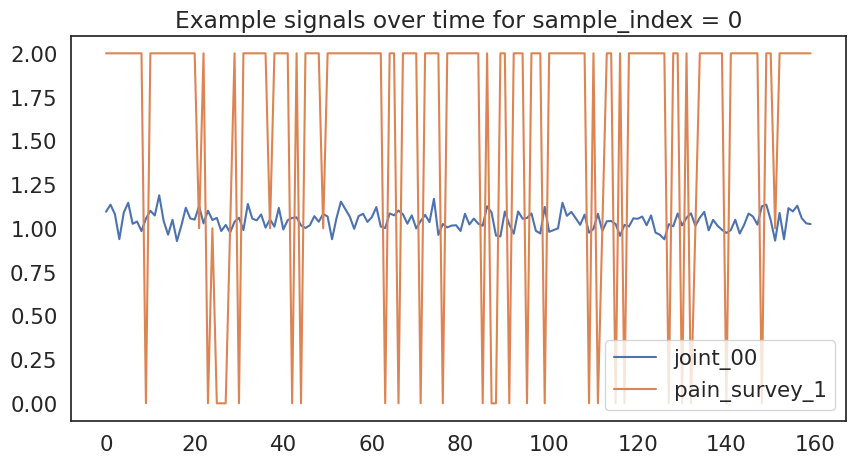

In [ ]:
subject = dataset_train[dataset_train['sample_index'] == 0]

plt.figure(figsize=(10,5))
plt.plot(subject['time'], subject['joint_00'], label='joint_00')
plt.plot(subject['time'], subject['pain_survey_1'], label='pain_survey_1')
plt.legend()
plt.title('Example signals over time for sample_index = 0')
plt.show()

Find the kept-up average line,

In [ ]:
selector = VarianceThreshold(threshold=1e-5)
selector.fit(dataset_train.select_dtypes(float))

low_var_cols = dataset_train.select_dtypes(float).columns[~selector.get_support()]
print("Low variance features:", low_var_cols.tolist())


Low variance features: ['joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_23', 'joint_24', 'joint_30']


This lines are to find sensors with unusually large or unstable values.

In [ ]:
stats = dataset_train.describe().T
stats['range'] = stats['max'] - stats['min']
stats['std_over_mean'] = stats['std'] / stats['mean'].abs()

stats[['range', 'std_over_mean']].sort_values('std_over_mean', ascending=False).head(10)

,range,std_over_mean
joint_22,1.305001,131.015423
joint_21,1.442198,125.235102
joint_23,0.274241,34.686300
joint_25,0.947354,31.291376
joint_19,0.616061,20.430056
joint_20,1.096014,20.275951
joint_14,0.264232,18.363109
joint_18,0.728382,17.025618
joint_16,0.188807,15.010470
joint_13,0.073852,13.007174


The ones that we need to remove are:

['joint_13','joint_14', 'joint_15','joint_16','joint_18','joint_19','joint_20',
  'joint_21','joint_22','joint_23','joint_24','joint_25','joint_30']

# Class imbalance Solution

In [ ]:
classes = np.unique(dataset_labels['label'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=dataset_labels['label']
)
class_weights = dict(zip(classes, class_weights))
print(class_weights)


{'high_pain': np.float64(3.9345238095238093), 'low_pain': np.float64(2.3439716312056738), 'no_pain': np.float64(0.43118069145466403)}


# Remove unnecessary or noisy features


In [ ]:
# List of noisy / unnecessary features
noisy_features = [
    'joint_13', 'joint_14', 'joint_15', 'joint_16',
    'joint_18', 'joint_19', 'joint_20', 'joint_21',
    'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_30'
]

# Remove them off the dataset
dataset_train_clean = dataset_train.drop(columns=[c for c in noisy_features if c in dataset_train.columns], errors='ignore')
dataset_test_clean  = dataset_test.drop(columns=[c for c in noisy_features if c in dataset_test.columns], errors='ignore')

print("✅ Removed noisy features.")
print(f"Original dataset_train shape: {dataset_train.shape}")
print(f"Cleaned  dataset_train shape: {dataset_train_clean.shape}")
print(f"Original dataset_test shape:  {dataset_test.shape}")
print(f"Cleaned  dataset_test shape:  {dataset_test_clean.shape}")


✅ Removed noisy features.
Original dataset_train shape: (105760, 40)
Cleaned  dataset_train shape: (105760, 27)
Original dataset_test shape:  (211840, 40)
Cleaned  dataset_test shape:  (211840, 27)


1: Define Features and hyperparameters

In [ ]:
#1 Labels
# Map the string labels to integer values
label_to_id = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
id_to_label = {v: k for k, v in label_to_id.items()}
num_classes = len(label_to_id)

# Apply the mapping to your label dataframe
dataset_labels['label_id'] = dataset_labels['label'].map(label_to_id)

# 2. Define the feature columns ---
# These are the columns that remain *after* your cleaning [cite: 1690, 1699] and we exclude 'sample_index' and 'time'

feature_cols = [col for col in dataset_train_clean.columns if col not in ['sample_index', 'time', 'n_legs', 'n_hands', 'n_eyes']]
print(f"We will use {len(feature_cols)} columns of features")

# 3. Define Global Hyperparameters
WIN_SIZE = 160       # Each sample has 160 time steps
STRIDE = 1           # We don't need stride here (I think)
BATCH_SIZE = 64      # You can adjust this (64 or 128 is a good starting point)
HIDDEN_SIZE = 128    # Neurons in the LSTM
NUM_LAYERS = 2       # LSTM layers
DROPOUT_RATE = 0.2   # Dropout for regularization
LEARNING_RATE = 1e-3 # Learning rate
EPOCHS = 50          # Number of epochs (add early stopping later)
PATIENCE = 50        # Patience for early stopping

We will use 22 columns of features


STEP 2: (Train/Validation)

In [ ]:
all_sample_indices = dataset_labels['sample_index'].unique()
labels_for_split = dataset_labels['label_id'].values

# Split the sample IDs (stratified by pain label)
# This ensures that the proportion of 'no_pain', 'low_pain' and 'high_pain' is similar in both sets.
train_ids, val_ids = train_test_split(
    all_sample_indices,
    test_size=0.2, # 20% for validation
    random_state=SEED,
    stratify=labels_for_split
)

print(f"Total of people: {len(all_sample_indices)}")
print(f"For training: {len(train_ids)}")
print(f"For validation: {len(val_ids)}")

Total of people: 661
For training: 528
For validation: 133


Step 3: Tensores and DataLoaders

In [ ]:
# Lookup dictionary for the labels (id -> label)
# Created from the label dataframe
labels_dict = dataset_labels.set_index('sample_index')['label_id'].to_dict()
# We group the main dataframe by 'sample_index' for super-fast access
# we use the cleaned dataframe
grouped_train_features = dataset_train_clean.groupby('sample_index')

def create_dataset_from_ids(ids, features_grouped, feature_cols):
    """
    Create tensors X (features) and y (labels) from a list of sample IDs.
    """
    X_list = []
    y_list = []

    for sample_id in ids:
        # Get the sequence of 160 time steps for this ID
        sequence_df = features_grouped.get_group(sample_id)

        # Select only the feature columns and convert to numpy
        # Shape will be (160, num_features)
        features_np = sequence_df[feature_cols].values

        # Add to the list
        X_list.append(features_np)

        # Get the corresponding label (a single number: 0, 1, or 2)
        label = labels_dict[sample_id]
        y_list.append(label)

    # Convert lists to PyTorch tensors
    # X shape: (N, 160, num_features) -> e.g. [528, 160, 27]
    # y shape: (N) -> e.g. [528]
    X_tensor = torch.tensor(np.array(X_list), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(y_list), dtype=torch.long)

    return X_tensor, y_tensor

#Create datasets
print("Create tensor for training...")
X_train, y_train = create_dataset_from_ids(train_ids, grouped_train_features, feature_cols)
print("Create tensor for validation...")
X_val, y_val = create_dataset_from_ids(val_ids, grouped_train_features, feature_cols)

print(f"\nForma de X_train (features): {X_train.shape}")
print(f"Forma de y_train (labels): {y_train.shape}")
print(f"Forma de X_val (features): {X_val.shape}")
print(f"Forma de y_val (labels): {y_val.shape}")

# Create DataLoaders
# TensorDataset combines the tensors X and y into a dataset.
train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)

# DataLoader load in batches and shuffle
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

Create tensor for training...
Create tensor for validation...

Forma de X_train (features): torch.Size([528, 160, 22])
Forma de y_train (labels): torch.Size([528])
Forma de X_val (features): torch.Size([133, 160, 22])
Forma de y_val (labels): torch.Size([133])


STEP 3.5 (problems with balance)

In [ ]:
# 3.5: Aply SMOTE for balance 'high_pain' y 'low_pain'because high pain is not getting results
!pip install -U imbalanced-learn
from imblearn.over_sampling import SMOTE

# SMOTE works on 2D data (n_samples, n_features)
# Our data is 3D (n_samples, 160, 22)

# 1. Save the original 3D shape
n_samples, n_timesteps, n_features = X_train.shape

# 2. Flatten X_train to 2D
# (n_samples, 160 * 22)
X_train_2d = X_train.reshape(n_samples, n_timesteps * n_features)

# 3. Initialize SMOTE
smote = SMOTE(random_state=SEED, k_neighbors=5)
# k_neighbors must be smaller than the smallest class (high_pain)
# First, let's find out how many 'high_pain' samples you have in the training set:
n_high_pain_train = (y_train == label_to_id['high_pain']).sum().item()

if n_high_pain_train <= smote.k_neighbors:
# If you have very few samples (e.g., 5 or fewer), SMOTE will raise an error.
# We reduce k_neighbors to a safe value.

    smote.k_neighbors = max(1, n_high_pain_train - 1)
    print(f"WARNING: Few 'high_pain' samples ({n_high_pain_train}). Adjusting SMOTE k_neighbors to {smote.k_neighbors}.")

if smote.k_neighbors > 0:
    print(f"Original shape of X_train (2D): {X_train_2d.shape}")
    print(f"Original distribution of y_train: {np.bincount(y_train)}")

    # 4. Apply SMOTE
    # This creates new synthetic samples for 'high_pain' and 'low_pain'
    # until they match the number of 'no_pain' samples.

    X_train_smote_2d, y_train_smote = smote.fit_resample(X_train_2d, y_train)

    print(f"\nShape of X_train after SMOTE (2D): {X_train_smote_2d.shape}")
    print(f"Distribution of y_train after SMOTE: {np.bincount(y_train_smote)}")

   # 5. Reshape the oversampled X_train back to 3D
    X_train_smote_3d = X_train_smote_2d.reshape(-1, n_timesteps, n_features)

    # RE-CREATE THE TRAINING DATALOADER
    # We use the new SMOTE data
    train_ds = TensorDataset(torch.tensor(X_train_smote_3d, dtype=torch.float32),
                             torch.tensor(y_train_smote, dtype=torch.long))

    val_ds = TensorDataset(X_val, y_val)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    print("\n¡DataLoaders data from SMOTE (training) y original data (validation)!")

else:
    print("ERROR: No se pudo aplicar SMOTE porque hay muy pocas muestras de 'high_pain' (o 0).")
    print("Continuando sin SMOTE...")

Original shape of X_train (2D): torch.Size([528, 3520])
Original distribution of y_train: [408  75  45]

Shape of X_train after SMOTE (2D): (1224, 3520)
Distribution of y_train after SMOTE: [408 408 408]

¡DataLoaders data from SMOTE (training) y original data (validation)!


Paso 4: Define model LSTM

In [ ]:
class RecurrentClassifier(nn.Module):
    """
    Clasificador RNN  (RNN, LSTM, GRU)
    """
    def __init__(
        self,
        input_size,         # N° features
        hidden_size,        # N° neurons in hiddden layer
        num_layers,         # N° layers
        num_classes,        # N° clases output (ej. 3 para 'no_pain', 'low_pain', 'high_pain')
        rnn_type='GRU',     # RNN to use: 'RNN', 'LSTM', o 'GRU'
        bidirectional=False,# if True,  RNN = bidireccional
        dropout_rate=0.2
    ):
        super().__init__()
        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map to selecct the correct PyTorch
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }
        if rnn_type not in rnn_map:
            raise ValueError("rnn_type debe ser 'RNN', 'LSTM', o 'GRU'")
        rnn_module = rnn_map[rnn_type]
        dropout_val = dropout_rate if num_layers > 1 else 0
        # 1. Recurrent Layer
        # This is the main layer (use LSTM)
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,         # Specify that the input shape is (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # 2. Classification Layer
        # Compute the input size for the final layer
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concatena adelante y atrás
        else:
            classifier_input_size = hidden_size
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
    # x shape: (batch_size, seq_length, input_size)
    # rnn_out contains the outputs from *each* time step
    # hidden contains the *final* hidden state
    # rnn_out shape: (batch, seq_len, hidden_size * num_directions)
    # hidden shape: (num_layers * num_directions, batch, hidden_size)
        rnn_out, hidden = self.rnn(x)
        if self.rnn_type == 'LSTM':
            hidden = hidden[0] # we take only h_n

        # 'hidden' is now the hidden state h_n
        # shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # We want the final hidden state from the last layer, from both directions
            # Rearrange to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
            # Concatenate the last forward (hidden[-1, 0, ...]) and backward (hidden[-1, 1, ...]) states
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # If not bidirectional, we just take the hidden state from the last layer
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Pass the final hidden state vector through the classifier
        logits = self.classifier(hidden_to_classify)
        return logits

Step 5: Define functions for training

In [ ]:
if 'dataset_labels' not in locals():
    print("Cargando 'pirate_pain_train_labels.csv'...")
    dataset_labels = pd.read_csv('pirate_pain_train_labels.csv')

classes = np.unique(dataset_labels['label'])
class_weights_calc = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=dataset_labels['label']
)
class_weights_map = dict(zip(classes, class_weights_calc))
print(f"Pesos calculados : {class_weights_map}")

class_weights_tensor = torch.tensor([class_weights_map[c] for c in classes], dtype=torch.float).to(device)
print(f"Weight tensor created on the device: {class_weights_tensor.device}")

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print("\n # Criterion created with class weights:")
print(criterion) #show the weights

def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_targets = []
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')
    return epoch_loss, epoch_f1

def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')
    return epoch_loss, epoch_f1

def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device, patience, experiment_name):
    training_history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    patience_counter = 0
    best_metric = -1.0
    best_epoch = 0
    print(f"Comenzando entrenamiento para {experiment_name}...")
    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_loss, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)
        print(f"Epoch {epoch:02d}/{epochs} | Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | Val: Loss={val_loss:.4f}, F1={val_f1:.4f}")

        if val_f1 > best_metric:
            best_metric = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), f"models/{experiment_name}_best.pt")
            print(f"  -> Nuevo mejor F1-score: {best_metric:.4f}. Modelo guardado.")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping activado después de {epoch} epochs.")
                break

    print(f"\nTraining Finish. Best F1-score: {best_metric:.4f} (find on epoch {best_epoch})")
    try:
        model.load_state_dict(torch.load(f"models/{experiment_name}_best.pt"))
        print(f"best model /{experiment_name}_best.pt'")
    except FileNotFoundError:
        print("No se pudo restaurar el modelo.")
    return model, training_history

print("\nFunciones 'fit', 'train_one_epoch' y 'validate_one_epoch' definidas.")

Pesos calculados : {'high_pain': np.float64(3.9345238095238093), 'low_pain': np.float64(2.3439716312056738), 'no_pain': np.float64(0.43118069145466403)}
Weight tensor created on the device: cuda:0

 # Criterion created with class weights:
CrossEntropyLoss()

Funciones 'fit', 'train_one_epoch' y 'validate_one_epoch' definidas.


STEP 6

In [ ]:
!mkdir -p models

#1. Instantiate the LSTM Model
lstm_model = RecurrentClassifier(
    input_size=len(feature_cols), # N° features
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=num_classes,
    rnn_type='LSTM',          # <--- define LSTM
    bidirectional=True,       # bidirectional or not
    dropout_rate=DROPOUT_RATE
).to(device)

# 2. Optimizer and Scaler
optimizer = optim.AdamW(lstm_model.parameters(), lr=LEARNING_RATE)
scaler = GradScaler(enabled=(device.type == 'cuda'))

# 3. Train
lstm_model, history = fit(
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    patience=PATIENCE,
    experiment_name="lstm_baseline"
)

Comenzando entrenamiento para lstm_baseline...
Epoch 01/50 | Train: Loss=0.8991, F1=0.1917 | Val: Loss=0.4848, F1=0.6760
  -> Nuevo mejor F1-score: 0.6760. Modelo guardado.
Epoch 02/50 | Train: Loss=0.8514, F1=0.1667 | Val: Loss=0.5039, F1=0.6760
Epoch 03/50 | Train: Loss=0.7956, F1=0.2633 | Val: Loss=0.5476, F1=0.7196
  -> Nuevo mejor F1-score: 0.7196. Modelo guardado.
Epoch 04/50 | Train: Loss=0.8442, F1=0.3194 | Val: Loss=0.4743, F1=0.6760
Epoch 05/50 | Train: Loss=0.7840, F1=0.2742 | Val: Loss=0.6339, F1=0.6717
Epoch 06/50 | Train: Loss=0.8216, F1=0.3121 | Val: Loss=0.4645, F1=0.6932
Epoch 07/50 | Train: Loss=0.7517, F1=0.2674 | Val: Loss=0.5099, F1=0.7142
Epoch 08/50 | Train: Loss=0.6776, F1=0.3797 | Val: Loss=0.9346, F1=0.4121
Epoch 09/50 | Train: Loss=0.6691, F1=0.4131 | Val: Loss=0.3413, F1=0.7571
  -> Nuevo mejor F1-score: 0.7571. Modelo guardado.
Epoch 10/50 | Train: Loss=0.6289, F1=0.4376 | Val: Loss=0.3075, F1=0.7412
Epoch 11/50 | Train: Loss=0.5942, F1=0.4237 | Val: Loss=0

Results

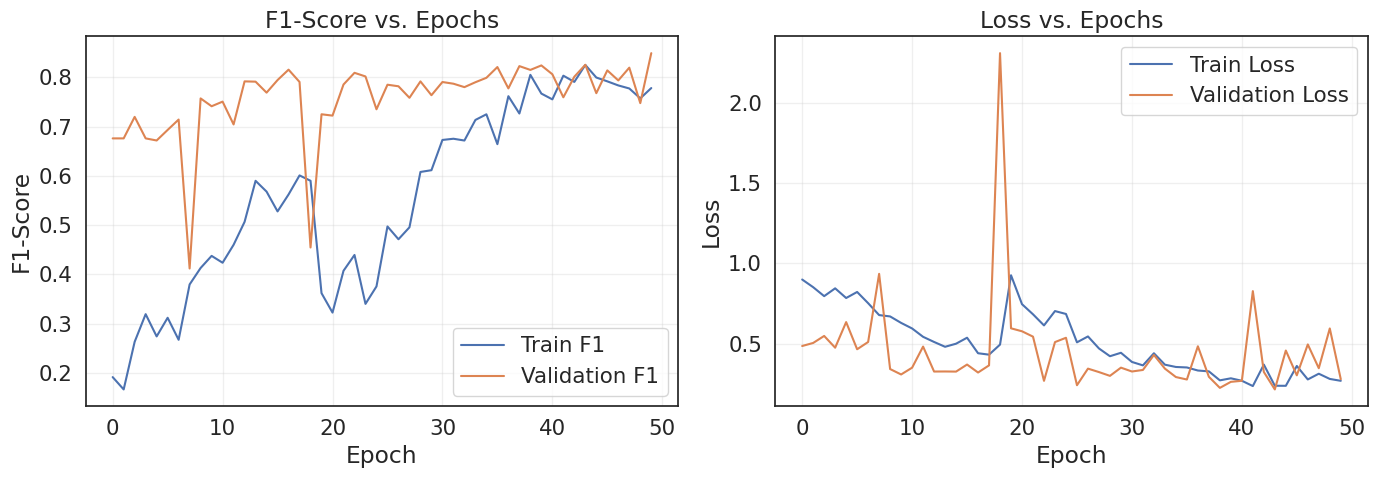

In [ ]:
def plot_history(history):
    """
    Plot F1-score and Loss of training and validation
    """
    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

    # --- Gráfico de F1-score ---
    ax1.plot(history['train_f1'], label='Train F1')
    ax1.plot(history['val_f1'], label='Validation F1')
    ax1.set_title('F1-Score vs. Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('F1-Score')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    #Plot Loss
    ax2.plot(history['train_loss'], label='Train Loss')
    ax2.plot(history['val_loss'], label='Validation Loss')
    ax2.set_title('Loss vs. Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot training history
try:
    plot_history(history)
except NameError:
    print("variable 'history' not defined")

In [ ]:
try:
    all_val_preds = []
    all_val_targets = []

    lstm_model.eval()

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)

            # obtein logits
            logits = lstm_model(inputs)
            predictions = logits.argmax(dim=1).cpu().numpy()

            all_val_preds.append(predictions)
            all_val_targets.append(targets.cpu().numpy())

    # Concatenated the results of the batches
    y_pred = np.concatenate(all_val_preds)
    y_true = np.concatenate(all_val_targets)
    target_names = [id_to_label[i] for i in range(num_classes)]

    print("\nValidation classification report (LSTM):")
    print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

except NameError as e:
    print(f"Error: {e}")
    print("make sure 'lstm_model', 'val_loader', 'id_to_label' y 'num_classes' exist.")
except Exception as e:
    print(f"error: {e}")


Validation classification report (LSTM):
              precision    recall  f1-score   support

     no_pain     0.8850    0.9709    0.9259       103
    low_pain     0.8000    0.6316    0.7059        19
   high_pain     0.6000    0.2727    0.3750        11

    accuracy                         0.8647       133
   macro avg     0.7617    0.6251    0.6689       133
weighted avg     0.8493    0.8647    0.8489       133

